# Headline

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download

In [70]:
!pip install boruta
!pip install bayesian-optimization

## Import

In [71]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# feature selection methods imports
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ks_2samp
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from boruta import BorutaPy

# model & tuning imports
from sklearn.ensemble import RandomForestClassifier
from bayes_opt import BayesianOptimization

# validation imports
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve

# Data( Cleaned) Input

In [72]:
data = pd.read_csv('/content/drive/MyDrive/COURSES/Extension Projects/Code/Data Sources/DIG_data_set.csv')

data

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,roll_std_20,roll_skew_20,roll_kurt_20,z_score,hurst,garch_volatility,vwap,dist_vwap,force_index,amihud_illiq
0,3.97,3.97,3.88,3.92,330350,-3.315119e+06,2.337267e+07,0.138525,27776.175622,1.084574e+00,...,0.016394,1.365938,1.814575,1.288174,0.426577,2.135037,3.496148,0.121234,-16517.5,3.836670e-08
1,3.88,3.97,3.88,3.97,1024510,-3.351825e+06,2.304232e+07,0.066923,21448.507676,-1.089753e+00,...,0.016452,1.338127,1.706333,1.661042,0.411756,2.096880,3.504302,0.132893,51225.5,1.237122e-08
2,3.97,4.01,3.84,3.84,338710,-2.327315e+06,2.406683e+07,0.185013,25702.363722,0.000000e+00,...,0.018319,0.828901,1.255185,0.106307,0.401965,2.043220,3.506671,0.095056,-44032.3,9.829568e-08
3,3.84,3.92,3.84,3.88,515370,-2.666025e+06,2.372812e+07,0.135271,15740.268905,-1.114451e-14,...,0.018434,0.727332,1.033995,0.514296,0.398486,2.266218,3.510069,0.105392,20614.8,2.010747e-08
4,4.08,4.08,3.91,4.00,761700,-2.666025e+06,2.424349e+07,0.137100,16436.630490,-6.985273e-01,...,0.019524,0.541149,0.183091,1.696173,0.395522,2.198163,3.516527,0.137486,91404.0,3.998846e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,13.54,14.10,13.45,13.84,15060300,-6.898748e+08,1.771278e+09,-0.260383,131040.816306,-6.067245e-01,...,0.023348,-1.697352,4.326719,1.282793,0.583102,2.363450,21.129265,-0.344984,3162663.0,1.015232e-09
2239,13.93,13.97,13.67,13.71,6530700,-6.868627e+08,1.786339e+09,-0.191036,564129.699691,-1.942192e-01,...,0.022613,-1.687347,4.493780,0.968153,0.586032,2.307681,21.126193,-0.351043,-848991.0,1.445091e-09
2240,13.80,13.80,13.50,13.67,8952900,-6.916519e+08,1.779808e+09,-0.295668,362255.314020,2.067160e-01,...,0.022626,-1.662990,4.421019,0.859906,0.589697,2.232597,21.121915,-0.352805,-358116.0,3.263571e-10
2241,13.67,13.93,13.50,13.76,12181700,-6.904582e+08,1.770855e+09,-0.295142,259345.126303,-5.696478e-01,...,0.021814,-2.001291,6.211229,0.965136,0.591952,2.132916,21.116158,-0.348366,1096353.0,5.386918e-10


## data train-test split

In [73]:
df = data.copy()
df[['ret']] = df[['ret']].shift(-1)
df.dropna(inplace=True)

print(f"input data shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")

input data shape: (2242, 103)
columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 't

# Feature Engineering

## Causality Test

In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import grangercausalitytests

# --- PART 1: The Granger Function ---
def get_best_granger_features(data, target_col, features, max_lag=5):
    """
    Tests Granger Causality for each feature against the target.
    Returns:
        1. best_lags: Dict {feature_name: optimal_lag}
        2. results_df: DataFrame with detailed stats
    """
    best_lags = {}
    detailed_results = []

    print(f"Starting Granger Causality Test on {len(features)} features...")

    for feature in features:
        # Skip if the feature is the target itself
        if feature == target_col:
            continue

        # Create a temp df with just the two columns we care about
        # Order matters for statsmodels: [Target, Predictor]
        # We are testing: Does 'feature' Granger-cause 'target_col'?
        test_df = data[[target_col, feature]].dropna()

        # Safety check: Ensure columns are numeric and have enough variance
        if not np.issubdtype(test_df[feature].dtype, np.number) or test_df[feature].nunique() <= 1:
            continue

        try:
            # verbose=False prevents it from spamming your console
            test_output = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
        except Exception as e:
            # Common errors: Singular matrix (collinearity), constant data
            # print(f"Skipping {feature}: {e}")
            continue

        # Track the best lag for this specific feature
        best_f_score = -1
        best_lag_for_feature = -1
        is_significant = False

        for lag, result in test_output.items():
            # result[0] contains the test stats
            # 'ssr_ftest' is the F-test for the Granger causality
            f_stat = result[0]['ssr_ftest'][0]
            p_val = result[0]['ssr_ftest'][1]

            # Save details for review
            detailed_results.append({
                'Feature': feature,
                'Lag': lag,
                'F_Statistic': f_stat,
                'P_Value': p_val
            })

            # Check for significance (p < 0.05) and maximizing F-stat
            if p_val < 0.05:
                is_significant = True
                if f_stat > best_f_score:
                    best_f_score = f_stat
                    best_lag_for_feature = lag

        # Only keep the feature if it had at least one significant lag
        if is_significant:
            best_lags[feature] = best_lag_for_feature

    results_df = pd.DataFrame(detailed_results)
    return best_lags, results_df

def engineer_asymmetry(df):
    df = df.copy()

    # 1. Semi-Variance (Downside vs Upside Volatility)
    # Isolates the volatility of only the positive days vs only the negative days
    df['ret_pos'] = df['ret'].clip(lower=0)
    df['ret_neg'] = df['ret'].clip(upper=0)

    df['volatility_upside'] = df['ret_pos'].rolling(window=window).std()
    df['volatility_downside'] = df['ret_neg'].rolling(window=window).std()

    # The Asymmetry Ratio: Spikes when downside volatility dominates, drops when market stabilizes
    df['vol_asymmetry_ratio'] = df['volatility_upside'] / (df['volatility_downside'] + 1e-6)

    # 2. Cumulative Drawdown (The "Buy the Dip" detector)
    # Using a cumulative product of returns as a price proxy if raw 'close' isn't available
    df['price_proxy'] = (1 + df['ret']).cumprod()
    df['roll_max_20'] = df['price_proxy'].rolling(window=window).max()

    # Measures how far we are from the recent local high (always 0 or negative)
    df['drawdown_20'] = (df['price_proxy'] - df['roll_max_20']) / (df['roll_max_20'] + 1e-6)

    # 3. Drawdown Velocity (Is the crash accelerating or exhausting?)
    df['drawdown_velocity'] = df['drawdown_20'].diff()

    # Clean up temporary columns
    df.drop(columns=['ret_pos', 'ret_neg', 'price_proxy', 'roll_max_20'], inplace=True)

    return df

## Relative Strength & Cross-Asset Correlation

In [75]:
import pandas as pd
import numpy as np

def engineer_cross_asset(df, asset_col='Close', benchmark_col='spy_close', window=20):
    df = df.copy()

    # 1. Relative Strength Ratio (Asset Price / Benchmark Price)
    df['relative_strength_ratio'] = df[asset_col] / (df[benchmark_col] + 1e-8)

    # 2. Relative Strength Momentum (Is the outperformance accelerating?)
    df['rs_momentum'] = df['relative_strength_ratio'].pct_change(periods=5)

    # 3. Rolling Beta (Covariance / Variance)
    asset_ret = df[asset_col].pct_change()
    bench_ret = df[benchmark_col].pct_change()

    rolling_cov = asset_ret.rolling(window).cov(bench_ret)
    rolling_var = bench_ret.rolling(window).var()

    df['rolling_beta'] = rolling_cov / (rolling_var + 1e-8)

    return df

## Volatility Term Structure

In [76]:
def engineer_vol_term_structure(df, target_col='ret', short_window=5, long_window=20):
    df = df.copy()

    # Calculate realized volatility (standard deviation of returns)
    short_vol = df[target_col].rolling(window=short_window).std()
    long_vol = df[target_col].rolling(window=long_window).std()

    # Volatility Term Structure Ratio
    # > 1.0 means short-term panic (backwardation)
    # < 1.0 means normal market conditions (contango)
    df['vol_term_structure'] = short_vol / (long_vol + 1e-8)

    # Volatility Acceleration (Is panic increasing?)
    df['vol_acceleration'] = df['vol_term_structure'].diff()

    return df

## Volume Profile & Order Flow

In [77]:
def engineer_order_flow(df, window=5):
    df = df.copy()

    # Typical Price
    typical_price = (df['High'] + df['Low'] + df['Close']) / 3.0

    # Rolling VWAP
    rolling_vol_price = (typical_price * df['Volume']).rolling(window=window).sum()
    rolling_vol = df['Volume'].rolling(window=window).sum()

    df[f'vwap_{window}d'] = rolling_vol_price / (rolling_vol + 1e-8)

    # Distance from VWAP (Positive = buyers in profit, Negative = buyers underwater)
    df['vwap_distance'] = (df['Close'] - df[f'vwap_{window}d']) / (df[f'vwap_{window}d'] + 1e-8)

    return df

## Market Regime Filter (Unsupervised Machine Learning)

In [78]:
from sklearn.mixture import GaussianMixture

def engineer_market_regime(df, return_col='ret', n_regimes=3):
    df = df.copy()

    # Prepare the input features for the GMM
    # We use 10-day return momentum and 10-day volatility
    df['regime_ret_10d'] = df[return_col].rolling(10).sum()
    df['regime_vol_10d'] = df[return_col].rolling(10).std()

    # Drop NaNs just for fitting the GMM
    regime_data = df[['regime_ret_10d', 'regime_vol_10d']].dropna()

    # Fit the Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_regimes, random_state=42, n_init=5)
    gmm.fit(regime_data)

    # Predict the regime (Outputs an integer: 0, 1, or 2)
    regime_preds = gmm.predict(regime_data)

    # Realign predictions with the original dataframe index
    df['market_regime'] = np.nan
    df.loc[regime_data.index, 'market_regime'] = regime_preds

    # Clean up temporary columns
    df.drop(columns=['regime_ret_10d', 'regime_vol_10d'], inplace=True)

    return df

## Executing

### train-test setting up

In [79]:
# ==========================================
# PHASE 1: ADVANCED CONTEXT FEATURE CREATION
# (Run this on your full, unsplit 'df')
# ==========================================

# NOTE: Ensure your 'df' still has 'high', 'low', 'close', 'volume', and a merged benchmark like 'spy_close'
'''
df = engineer_cross_asset(df, asset_col='Close', benchmark_col='spy_close', window=20)
'''
df = engineer_vol_term_structure(df, target_col='ret', short_window=5, long_window=20)
df = engineer_order_flow(df, window=5)
df = engineer_market_regime(df, return_col='ret', n_regimes=3)

# Drop NaNs created by the new 20-day rolling windows
df.dropna(inplace=True)

# (Optional) Now you can drop the raw OHLCV and benchmark columns if you strictly
# want the model to learn from the derived indicators and context features, not raw prices.
'''
cols_to_drop = ['open', 'high', 'low', 'close', 'volume', 'spy_close']
'''
cols_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# ==========================================
# PHASE 2: THE TIME BARRIER (SPLITTING)
# ==========================================

# Split BEFORE doing any forward-looking target shifting or Granger scaling
train_df, test_df = train_test_split(df, test_size=0.2, shuffle=False)

### engineering process:

In [80]:
# ==========================================
# PHASE 3: GRANGER CAUSALITY TEST
# ==========================================

# Define features to test (exclude the current return to avoid testing it against itself)
feature_cols = [c for c in train_df.columns if c != 'ret']

# Run Granger Test on the UNSHIFTED return
best_lags, granger_stats = get_best_granger_features(
    data=train_df,
    target_col='ret',
    features=feature_cols,
    max_lag=5
)

print(f"\nGranger identified {len(best_lags)} significant features.")

# ==========================================
# PHASE 4: SCALING & KINEMATICS (Applying Lags)
# ==========================================

window = 20
warmup_buffer = train_df.tail(window)
full_test_df = pd.concat([warmup_buffer, test_df])

# 1. Apply Volatility-Scaled Lags
for feature, lag in best_lags.items():
    def get_aligned_scaling(df_in, feat, l):
        val_lagged = df_in[feat].shift(l)
        roll_mu = df_in[feat].rolling(window=window).mean().shift(l)
        roll_sigma = df_in[feat].rolling(window=window).std().shift(l)
        return (val_lagged - roll_mu) / (roll_sigma + 1e-6)

    col_name = f"{feature}_lag{lag}_scaled"
    train_df[col_name] = get_aligned_scaling(train_df, feature, lag)
    full_test_df[col_name] = get_aligned_scaling(full_test_df, feature, lag)

# 2. Apply Momentum & Acceleration
for feature, lag in best_lags.items():
    col_name_mom = f"{feature}_lag{lag}_momentum"
    train_df[col_name_mom] = (train_df[feature] - train_df[feature].shift(lag)) / (train_df[feature].shift(lag) + 1e-6)
    full_test_df[col_name_mom] = (full_test_df[feature] - full_test_df[feature].shift(lag)) / (full_test_df[feature].shift(lag) + 1e-6)

    col_name_acc = f"{feature}_lag{lag}_acceleration"
    train_df[col_name_acc] = train_df[col_name_mom].diff()
    full_test_df[col_name_acc] = full_test_df[col_name_mom].diff()

# Remove buffer and clean up
test_df = full_test_df.iloc[window:].copy()
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

Starting Granger Causality Test on 102 features...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


Granger identified 60 significant features.


/tmp/ipykernel_160/2667999755.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[col_name_mom] = (train_df[feature] - train_df[feature].shift(lag)) / (train_df[feature].shift(lag) + 1e-6)
/tmp/ipykernel_160/2667999755.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_test_df[col_name_mom] = (full_test_df[feature] - full_test_df[feature].shift(lag)) / (full_test_df[feature].shift(lag) + 1e-6)
/tmp/ipykernel_160/2667999755.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

### Engineer the Multi-Day:

In [81]:
# ==========================================
# PHASE 5: ASYMMETRY & TARGET ENGINEERING
# ==========================================

# Apply your asymmetry function
train_df = engineer_asymmetry(train_df)
test_df = engineer_asymmetry(test_df)

# Engineer the Multi-Day Forward Target (5-Day Cumulative Return)
horizon = 3
train_df[f'target_{horizon}d_ret'] = train_df['ret'].rolling(window=horizon).sum().shift(-horizon)
test_df[f'target_{horizon}d_ret'] = test_df['ret'].rolling(window=horizon).sum().shift(-horizon)

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# Data Cleaning:

## Leakage

In [83]:
def leakage_check(df, target, threshold=0.98):
    merged = df.copy()

    merged[target] = merged[target].shift(-1)
    merged.dropna(axis=0, inplace=True)

    corr = merged.corr()[target].drop(target)
    return corr[abs(corr) > threshold].index.tolist()

## Non-stationarity Remove

In [84]:
from statsmodels.tsa.stattools import adfuller

def non_stationary_features(df, alpha=0.05):
    non_stationary = []
    for col in df.columns:
        try:
            p = adfuller(df[col].dropna())[1]
            if p > alpha:
                non_stationary.append(col)
        except:
            non_stationary.append(col)
    return non_stationary

## Near-zero variance features

In [85]:
def low_variance_features(df, threshold=1e-6):
    return df.columns[df.var() < threshold].tolist()

## Severe missingness

In [86]:
def high_missing_features(df, threshold=0.2):
    return df.columns[df.isna().mean() > threshold].tolist()

### Check for "Streaks.”

In [87]:
def missing_streak_check(df, max_streak_threshold=10):
    streak_report = {}
    for col in df.columns:
        # Create a mask of where data is null
        is_null = df[col].isnull()

        # Count consecutive groups of True values
        streaks = is_null.groupby((is_null != is_null.shift()).cumsum()).sum()
        max_streak = streaks.max()

        if max_streak > max_streak_threshold:
            streak_report[col] = max_streak

    return streak_report

## Numerical instability

In [88]:
import numpy as np

def unstable_features(df):
    bad_cols = []
    for col in df.columns:
        if np.isinf(df[col]).any() or df[col].abs().max() > 1e6:
            bad_cols.append(col)
    return bad_cols

## Duplicate information

In [89]:
def highly_correlated_features(df, threshold=0.95):
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [col for col in upper.columns if any(upper[col] > threshold)]

## Full pipeline

In [90]:
def pre_level2_feature_filter(df, target):
    remove = set()
    remove.update(low_variance_features(df))
    remove.update(high_missing_features(df))
    remove.update(unstable_features(df))
    remove.update(highly_correlated_features(df))
    remove.update(leakage_check(df, target))
    remove.update(non_stationary_features(df))

    clean_df = df.drop(columns=list(remove))
    return clean_df, list(remove)

df = train_df.copy()
clean_df, removed_features = pre_level2_feature_filter(df, f'target_{horizon}d_ret')

print(f"Removed {len(removed_features)} features.")
print(f"Remaining:")
display(clean_df)

Removed 81 features.
Remaining:


,volume_cmf,volume_em,volume_sma_em,volume_mfi,volatility_bbw,volatility_bbp,volatility_bbhi,volatility_bbli,volatility_kcw,volatility_kcp,...,vwap_lag2_momentum,vwap_lag2_acceleration,vwap_5d_lag5_momentum,vwap_5d_lag5_acceleration,vwap_distance_lag2_momentum,vwap_distance_lag2_acceleration,vol_asymmetry_ratio,drawdown_20,drawdown_velocity,target_3d_ret
64,-0.116471,-1.183486,0.413745,64.081348,12.106713,0.395935,0.0,0.0,5.004907,0.343137,...,-0.000280,0.000049,-0.013275,-0.001330,2.617693,3.671297,0.817002,-0.237172,0.062986,-0.05
65,-0.031441,-1.898534,0.031077,53.030027,11.201416,0.416026,0.0,0.0,5.018203,0.396078,...,-0.000324,-0.000045,-0.000294,0.012980,694.531830,691.914137,0.793692,-0.024897,0.212275,-0.05
66,0.037468,2.104279,-0.175675,55.612396,10.614815,0.673304,0.0,0.0,5.320197,0.925926,...,-0.000298,0.000026,0.006715,0.007009,3.881983,-690.649847,1.057579,-0.112656,-0.087759,0.09
67,0.008100,0.937559,-0.447792,54.296209,8.596132,0.745468,0.0,0.0,5.081741,0.937984,...,-0.000243,0.000055,0.008933,0.002218,-1.350201,-5.232184,1.515481,-0.077162,0.035494,0.05
68,0.106117,-0.752603,-0.132818,51.786100,8.593095,0.443300,0.0,0.0,4.790537,0.427984,...,-0.000283,-0.000039,0.011519,0.002586,-0.980330,0.369872,1.515481,-0.077162,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1789,0.039219,0.090641,0.597638,68.625731,26.120182,1.067050,1.0,0.0,8.194520,1.737257,...,0.000470,-0.000010,0.080874,0.006004,-0.363664,-0.296288,3.177875,20.697528,7.037036,-0.96
1790,0.073351,0.529628,0.756125,73.526640,28.691526,0.965712,0.0,0.0,8.333333,1.392272,...,0.000596,0.000126,0.094267,0.013393,-0.438296,-0.074632,2.835756,13.103393,-7.594135,-0.26
1791,0.220357,0.293035,0.944686,78.972563,30.902804,0.971884,0.0,0.0,8.023289,1.493222,...,0.000772,0.000176,0.092361,-0.001906,-0.939958,-0.501662,2.763851,18.039581,4.936188,-0.35
1792,0.156064,0.487106,0.732001,80.354264,31.739893,0.867983,0.0,0.0,8.189254,1.077560,...,0.000664,-0.000108,0.077655,-0.014705,-0.551496,0.388462,1.589613,-0.000000,-18.039581,1.74


# Train-test split:

In [111]:
### multi-target with dual-threshold
threshold = 0.005 # 0.5% boundary for noise

drop_cols = ['target_ret', 'ret', f'target_{horizon}d_ret']
X_train = train_df.loc[:, ~train_df.columns.isin(drop_cols + removed_features)]
X_test = test_df.loc[:, ~test_df.columns.isin(drop_cols + removed_features)]

# 1 for Significant UP, -1 for Significant DOWN, 0 for FLAT/NOISE
conditions_train = [
    train_df[f'target_{horizon}d_ret'] > threshold,
    train_df[f'target_{horizon}d_ret'] < -threshold
]
y_train = pd.Series(np.select(conditions_train, [1, -1], default=0), index=train_df.index)

conditions_test = [
    test_df[f'target_{horizon}d_ret'] > threshold,
    test_df[f'target_{horizon}d_ret'] < -threshold
]
y_test = pd.Series(np.select(conditions_test, [1, -1], default=0), index=test_df.index)

print(f"y_train value counts:\n{y_train.value_counts(normalize=True)}")
print(f"y_test value counts:\n{y_test.value_counts(normalize=True)}")

y_train value counts:
 1    0.521387
-1    0.447399
 0    0.031214
Name: proportion, dtype: float64
y_test value counts:
-1    0.492823
 1    0.480861
 0    0.026316
Name: proportion, dtype: float64


# Statistics Feature Selection

In [112]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_classif, mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr

def generate_statistical_ranking(X, y):
    """
    Evaluates all features across 5 statistical methods, converts scores to ranks,
    and calculates consensus (mean_rank) and disagreement (instability).
    """
    stat_ranks = pd.DataFrame(index=X.columns)

    # 1. ANOVA (Linear relationship)
    # Higher F-statistic = better rank
    f_stats, _ = f_classif(X, y)
    stat_ranks['ANOVA_Rank'] = pd.Series(f_stats, index=X.columns).rank(ascending=False)

    # 2. Mutual Information (Non-linear/Complex)
    # Higher MI score = better rank
    mi_scores = mutual_info_classif(X, y, random_state=42)
    stat_ranks['MI_Rank'] = pd.Series(mi_scores, index=X.columns).rank(ascending=False)

    # 3. Chi-Squared (Categorical/Frequency-based)
    # Must scale to positive values first. Higher Chi2 stat = better rank
    X_pos = MinMaxScaler().fit_transform(X)
    chi2_stats, _ = chi2(X_pos, y)
    stat_ranks['Chi2_Rank'] = pd.Series(chi2_stats, index=X.columns).rank(ascending=False)

    # 4. Spearman Correlation (Monotonic relationships)
    # Higher absolute correlation = better rank
    spearman_scores = [abs(spearmanr(X.iloc[:, i], y)[0]) for i in range(X.shape[1])]
    stat_ranks['Spearman_Rank'] = pd.Series(spearman_scores, index=X.columns).rank(ascending=False)

    # 5. Variance (Information spread)
    # Higher variance = better rank (mimicking the VarianceThreshold logic)
    variances = X.var()
    stat_ranks['Variance_Rank'] = variances.rank(ascending=False)

    # --- Consensus & Stability Scoring ---
    rank_cols = ['ANOVA_Rank', 'MI_Rank', 'Chi2_Rank', 'Spearman_Rank', 'Variance_Rank']

    # Mean Rank: Average standing across all 5 statistical tests
    stat_ranks['mean_rank'] = stat_ranks[rank_cols].mean(axis=1)

    # Instability: Standard deviation of ranks (how much the 5 tests disagree)
    stat_ranks['instability'] = stat_ranks[rank_cols].std(axis=1)

    # Sort by best overall consensus
    return stat_ranks.sort_values(by=['mean_rank', 'instability'])

# Execute on your training data
statistics_ranking = generate_statistical_ranking(X_train, y_train)

# View the top results
print(f"Total features evaluated: {len(statistics_ranking)}")
display(statistics_ranking.head(10))

Total features evaluated: 206


,ANOVA_Rank,MI_Rank,Chi2_Rank,Spearman_Rank,Variance_Rank,mean_rank,instability
momentum_tsi,23.0,37.0,36.0,25.0,26.0,29.4,6.580274
volatility_kcw,2.0,92.0,5.0,14.0,59.0,34.4,39.538589
volume_mfi,25.0,80.0,32.0,19.0,31.0,37.4,24.378269
vwap_lag2_scaled,3.0,21.0,7.0,95.0,63.0,37.8,39.839679
momentum_roc,8.0,84.0,47.0,12.0,39.0,38.0,30.716445
trend_mass_index,6.0,67.0,10.0,9.0,98.0,38.0,42.101069
trend_dpo_lag1_scaled,5.0,57.0,17.0,3.0,115.0,39.4,47.526835
trend_dpo,1.0,35.0,76.0,1.0,90.0,40.6,41.416180
trend_sma_slow_lag5_scaled,40.0,12.0,21.0,65.0,68.0,41.2,25.232915
trend_adx_pos,34.0,63.0,35.0,27.0,48.0,41.4,14.258331


## Removal

### mean distribution:

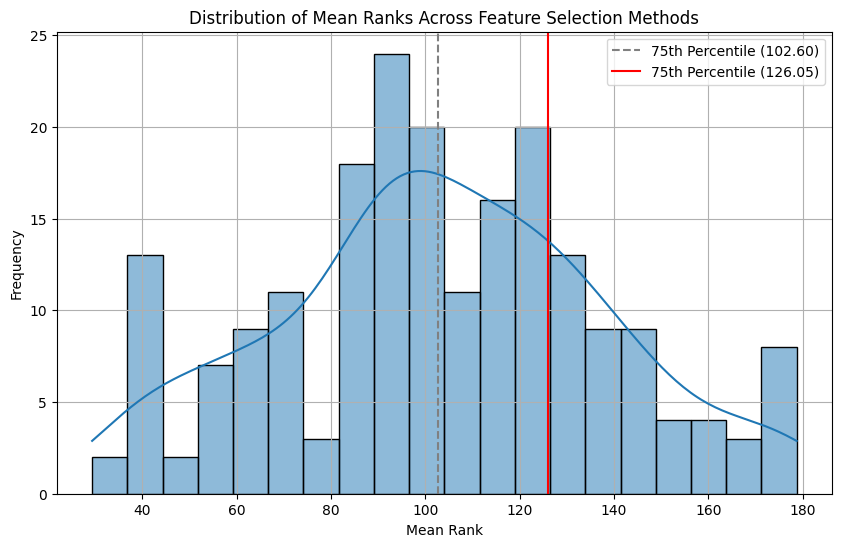

In [113]:
plt.figure(figsize=(10, 6))
sns.histplot(statistics_ranking['mean_rank'].sort_values(), kde=True, bins=20)
plt.title('Distribution of Mean Ranks Across Feature Selection Methods')
plt.xlabel('Mean Rank')
plt.ylabel('Frequency')
plt.grid(True)

# Calculate the 95th percentile of mean_rank
quantile = 0.75
significant_percentile = statistics_ranking['mean_rank'].sort_values().quantile(quantile)
half_percentile = statistics_ranking['mean_rank'].sort_values().quantile(0.5)

# Add a vertical line at the 95th percentile
plt.axvline(x=half_percentile, color='gray', linestyle='--', label=f'{int(quantile*100)}th Percentile ({half_percentile:.2f})')
plt.axvline(x=significant_percentile, color='red', label=f'{int(quantile*100)}th Percentile ({significant_percentile:.2f})')
plt.legend()
plt.show()

### stability distribution:

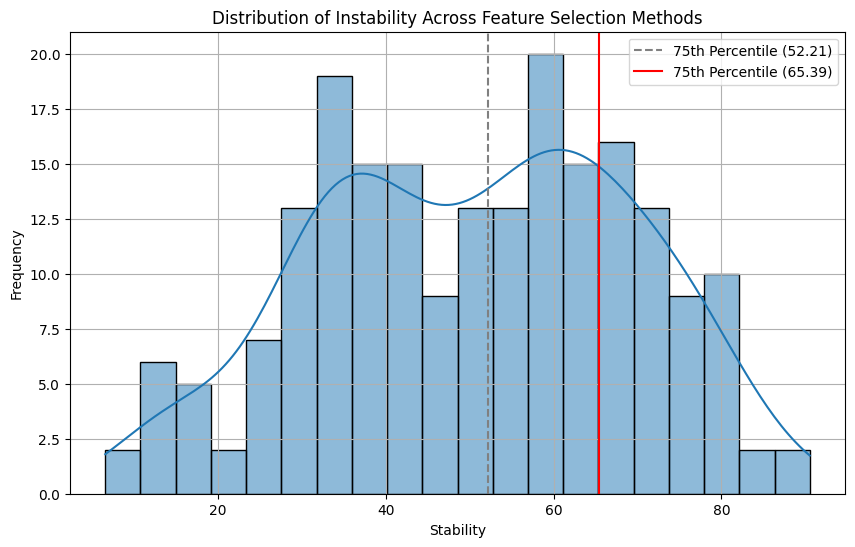

In [114]:
plt.figure(figsize=(10, 6))
sns.histplot(statistics_ranking['instability'].sort_values(), kde=True, bins=20)
plt.title('Distribution of Instability Across Feature Selection Methods')
plt.xlabel('Stability')
plt.ylabel('Frequency')
plt.grid(True)

# Calculate the 95th percentile of stability
sta_significant_percentile = statistics_ranking['instability'].sort_values().quantile(quantile)
half_percentile = statistics_ranking['instability'].sort_values().quantile(0.5)

# Add a vertical line at the 95th percentile
plt.axvline(x=half_percentile, color='gray', linestyle='--', label=f'{int(quantile*100)}th Percentile ({half_percentile:.2f})')
plt.axvline(x=sta_significant_percentile, color='red', label=f'{int(quantile*100)}th Percentile ({sta_significant_percentile:.2f})')
plt.legend()
plt.show()

## Elbow method

Recommended Rank Threshold: 82.60
Recommended Instability Threshold: 28.78


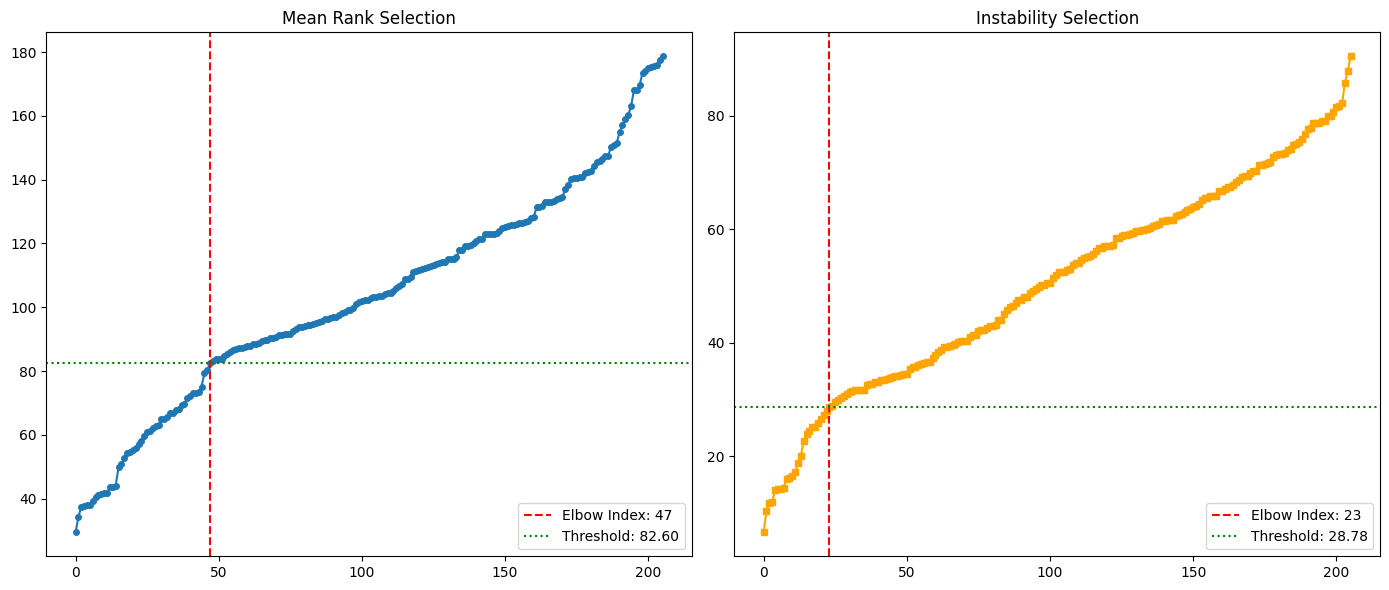

In [115]:
def get_elbow_threshold(series):
    """
    Finds the 'knee' point on a sorted curve using the vector distance method.
    """
    values = np.sort(series.values)
    n = len(values)
    coords = np.vstack((np.arange(n), values)).T

    # Vector for the line connecting start and end points
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))

    # Distance of each point to the line
    vec_from_first = coords - coords[0]
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - np.outer(scalar_proj, line_vec_norm))**2, axis=1))

    elbow_idx = np.argmax(dist_to_line)
    return values[elbow_idx], elbow_idx

# Calculate thresholds
rank_threshold, rank_idx = get_elbow_threshold(statistics_ranking['mean_rank'])
sta_threshold, sta_idx = get_elbow_threshold(statistics_ranking['instability'])

print(f"Recommended Rank Threshold: {rank_threshold:.2f}")
print(f"Recommended Instability Threshold: {sta_threshold:.2f}")

# Plotting the curves
plt.figure(figsize=(14, 6))

# Mean Rank Curve
plt.subplot(1, 2, 1)
plt.plot(np.sort(statistics_ranking['mean_rank']), 'o-', markersize=4)
plt.axvline(x=rank_idx, color='red', linestyle='--', label=f'Elbow Index: {rank_idx}')
plt.axhline(y=rank_threshold, color='green', linestyle=':', label=f'Threshold: {rank_threshold:.2f}')
plt.title('Mean Rank Selection')
plt.legend()

# Instability Curve
plt.subplot(1, 2, 2)
plt.plot(np.sort(statistics_ranking['instability']), 's-', markersize=4, color='orange')
plt.axvline(x=sta_idx, color='red', linestyle='--', label=f'Elbow Index: {sta_idx}')
plt.axhline(y=sta_threshold, color='green', linestyle=':', label=f'Threshold: {sta_threshold:.2f}')
plt.title('Instability Selection')
plt.legend()

plt.tight_layout()
plt.show()

# Fast tunning


In [130]:
statis_selected_features = statistics_ranking.loc[((statistics_ranking['mean_rank'] <= rank_threshold) & (statistics_ranking['instability'] <= sta_threshold)), :].index.tolist()

sub_X_train, sub_X_test = X_train.loc[:, statis_selected_features].copy(), X_test.loc[:, statis_selected_features].copy()
print(len(statis_selected_features))
print(statis_selected_features)

9
['momentum_tsi', 'volume_mfi', 'trend_sma_slow_lag5_scaled', 'trend_adx_pos', 'volatility_dch_lag5_scaled', 'momentum_rsi', 'trend_visual_ichimoku_b_lag5_scaled', 'volatility_atr_lag4_scaled', 'trend_vortex_ind_neg_lag1_scaled']


In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from bayes_opt import BayesianOptimization
import numpy as np

# 1. Define the function to maximize
def rf_cv(n_estimators, max_depth, min_samples_leaf, max_samples, max_features):
    """
    Stabilized Objective Function with Feature Control for Multi-Class.
    """
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        max_samples=max_samples,
        max_features=max_features,
        class_weight='balanced', # Crucial: Keeps the RF from ignoring the -1 and 1 classes
        random_state=42,
        n_jobs=-1
    )

    tscv = TimeSeriesSplit(n_splits=5)

    # FIX APPLIED HERE: Changed 'f1' to 'f1_macro'
    scores = cross_val_score(model, sub_X_train, y_train, cv=tscv, scoring='f1_macro')

    # Target: Reliability (Mean) minus Risk (StdDev)
    return scores.mean() - scores.std()

# 2. Updated "Impossible" Search Space
pbounds = {
    'n_estimators': (150, 400),
    'max_depth': (5, 20),
    'min_samples_leaf': (10, 50),
    'max_samples': (0.5, 0.8),
    'max_features': (0.2, 0.6)
}

# 3. Initialize and Optimize
optimizer = BayesianOptimization(
    f=rf_cv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# 4. Run Optimization
print("Starting Bayesian Optimization for Multi-Class F1-Macro...")
optimizer.maximize(init_points=5, n_iter=20)

# 5. Results and Final Model Preparation
print("-" * 30)
print(f"Best Score (F1-Macro - Penalty): {optimizer.max['target']:.4f}")
print(f"Best Parameters: {optimizer.max['params']}")

Starting Bayesian Optimization for Multi-Class F1-Macro...
|   iter    |  target   | n_esti... | max_depth | min_sa... | max_sa... | max_fe... |
-------------------------------------------------------------------------------------
| 1         | 0.2509568 | 243.63502 | 19.260714 | 39.279757 | 0.6795975 | 0.2624074 |
| 2         | 0.2454320 | 188.99863 | 5.8712541 | 44.647045 | 0.6803345 | 0.4832290 |
| 3         | 0.2416403 | 155.14612 | 19.548647 | 43.297705 | 0.5637017 | 0.2727299 |
| 4         | 0.2721913 | 195.85112 | 9.5636336 | 30.990257 | 0.6295835 | 0.3164916 |
| 5         | 0.2789562 | 302.96322 | 7.0924079 | 21.685785 | 0.6099085 | 0.3824279 |
| 6         | 0.2432105 | 301.88621 | 5.0800871 | 41.417801 | 0.6894920 | 0.3802895 |
| 7         | 0.2690790 | 248.84767 | 13.860810 | 21.401351 | 0.6378604 | 0.2809454 |
| 8         | 0.2721309 | 263.96745 | 16.504410 | 30.760248 | 0.5363074 | 0.2313590 |
| 9         | 0.2866838 | 176.77539 | 12.879383 | 16.381687 | 0.7478279 | 0.49737


## Model fitting check

In [118]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Extract and format the 'impossible' parameters
# Bayesian Optimization returns floats; we must cast to appropriate types.
params = optimizer.max['params']
#params['max_features'] = 'sqrt'

best_params_1 = {
    'n_estimators': int(params['n_estimators']),
    'max_depth': int(params['max_depth']),
    'min_samples_leaf': int(params['min_samples_leaf']),  # Switched to leaf for stability
    'max_samples': params['max_samples'],                # Fraction of data per tree
    'max_features': params['max_features'],               # Fraction of features per tree
    'class_weight': 'balanced',                          # Fixes the Class 1 precision gap
    'random_state': 42,
    'n_jobs': -1
}

# 1. Extract and format the 'impossible' parameters
# Bayesian Optimization returns floats; we must cast to appropriate types.
print(f"Best Parameters: {best_params_1}")

# 2. Initialize and fit the best model
# Using the optimized parameters found during the search
best_rf_model = RandomForestClassifier(**best_params_1)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(best_rf_model, sub_X_train, y_train, cv=tscv, scoring='accuracy')

print("--- Cross-Validation (CV) Test Results ---")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Stability (Std Dev): {np.std(cv_scores):.4f}")
print(f"Individual Fold Scores: {cv_scores}")
print("-" * 45)

# 3. Predict on the test set
# Ensure you use 'sub_X_test' to match the 'sub_X_train' used in training
best_rf_model.fit(sub_X_train, y_train)
y_pred_tuned = best_rf_model.predict(sub_X_test)

# 4. Results
print("\n--- Tuned Random Forest Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("-" * 45)
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'n_estimators': 350, 'max_depth': 20, 'min_samples_leaf': 10, 'max_samples': np.float64(0.5), 'max_features': np.float64(0.2), 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
--- Cross-Validation (CV) Test Results ---
Mean CV Accuracy: 0.4813
CV Stability (Std Dev): 0.0458
Individual Fold Scores: [0.4375     0.41666667 0.53472222 0.50347222 0.51388889]
---------------------------------------------

--- Tuned Random Forest Model Performance ---
Accuracy: 0.4976
---------------------------------------------
Classification Report:
              precision    recall  f1-score   support

          -1       0.50      0.60      0.54       206
           0       0.00      0.00      0.00        11
           1       0.50      0.42      0.46       201

    accuracy                           0.50       418
   macro avg       0.33      0.34      0.33       418
weighted avg       0.48      0.50      0.49       418



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Diagnosis

## Learning Curve

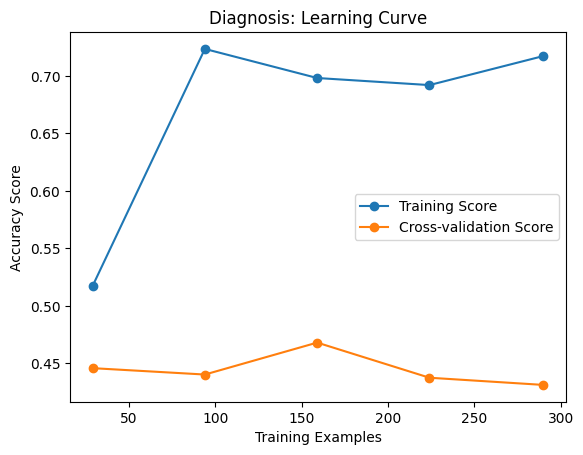

In [119]:
from sklearn.model_selection import learning_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

# --- 1. Learning Curve Diagnosis ---
def plot_learning_curve(model, X, y):

    tscv = TimeSeriesSplit(n_splits=5)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=tscv, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5)
    )

    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation Score")
    plt.title("Diagnosis: Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy Score")
    plt.legend()
    plt.show()

# Execution
rf = RandomForestClassifier(**best_params_1)
plot_learning_curve(rf, sub_X_train, y_train)

## Calibration Diagnostic

In [120]:
import pandas as pd

# 1. Get the probabilities
rf.fit(sub_X_train, y_train)
y_prob = rf.predict_proba(sub_X_test)[:, 1]

# 2. Create a DataFrame for analysis
results = pd.DataFrame({
    'actual': y_test,
    'prob': y_prob
})

# 3. Define confidence tiers
def check_precision(df, low, high):
    subset = df[(df['prob'] >= low) & (df['prob'] < high)]
    if len(subset) == 0: return 0, 0
    precision = subset['actual'].mean()
    return precision, len(subset)

# Diagnostic Printout
print("Confidence Tier | Precision (Accuracy) | Sample Count")
print("-" * 50)
for low, high in [(0, 0.35), (0.35, 0.45), (0.45, 0.55), (0.55, 0.65), (0.65, 1.0)]:
    prec, count = check_precision(results, low, high)
    # For low tiers, 'precision' is actually the accuracy of predicting Class 0
    if low < 0.45:
        display_prec = 1 - prec
        label = "Class 0"
    else:
        display_prec = prec
        label = "Class 1"
    print(f"{low:.2f} - {high:.2f}   | {display_prec:.2%} - {label}       | {count}")

Confidence Tier | Precision (Accuracy) | Sample Count
--------------------------------------------------
0.00 - 0.35   | 101.20% - Class 0       | 418
0.35 - 0.45   | 100.00% - Class 0       | 0
0.45 - 0.55   | 0.00% - Class 1       | 0
0.55 - 0.65   | 0.00% - Class 1       | 0
0.65 - 1.00   | 0.00% - Class 1       | 0


# Model-Oriented Feature Selection:

In [121]:
import pandas as pd
import numpy as np
from boruta import BorutaPy
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit

def optimize_rf_selectors(X, y):
    """
    Evaluates features based on absolute survival (Boruta) and absolute F1 impact (Permutation).
    """
    tscv = TimeSeriesSplit(n_splits=5)

    # DataFrames to store raw fold results
    boruta_hits = pd.DataFrame(index=X.columns)
    perm_impacts = pd.DataFrame(index=X.columns)

    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_test_fold, y_test_fold = X.iloc[test_idx], y.iloc[test_idx]

        # PRUNED RF: Max depth 5, class_weight balanced to force Class 1 attention
        rf = RandomForestClassifier(**best_params_1)

        # --- Method 1: Boruta (The Gatekeeper) ---
        # Boruta requires numpy arrays (.values)
        boruta_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42)
        boruta_selector.fit(X_train_fold.values, y_train_fold.values)

        # Record 1 if Boruta CONFIRMED the feature, 0 otherwise
        boruta_hits[f'Fold_{i}'] = (boruta_selector.ranking_ == 1).astype(int)

        # --- Method 2: Permutation Importance (The Ranker) ---
        rf.fit(X_train_fold, y_train_fold)

        # Permute on the UNSEEN test fold, scoring strictly on F1
        perm_result = permutation_importance(
            rf, X_test_fold, y_test_fold, n_repeats=5, scoring='f1_macro', n_jobs=-1, random_state=42
        )
        perm_impacts[f'Fold_{i}'] = perm_result.importances_mean

    # --- Aggregation ---
    final_eval = pd.DataFrame(index=X.columns)

    # 1. Boruta Hit Rate: % of time-folds where feature beat random noise
    final_eval['boruta_hit_rate'] = boruta_hits.mean(axis=1)

    # 2. Permutation Net Benefit: Average F1 drop when feature is removed
    final_eval['mean_f1_impact'] = perm_impacts.mean(axis=1)

    # 3. Permutation Stability: Standard deviation of F1 impact
    final_eval['f1_impact_std'] = perm_impacts.std(axis=1)

    return final_eval

# --- 1. Execute on Phase 1 Features ---
# Use the features that survived your statistical Elbow method
phase_2_eval = optimize_rf_selectors(X_train[statis_selected_features], y_train)
phase_2_eval

,boruta_hit_rate,mean_f1_impact,f1_impact_std
momentum_tsi,0.0,-0.007444,0.019902
volume_mfi,0.0,-0.000925,0.008886
trend_sma_slow_lag5_scaled,0.0,0.010097,0.016312
trend_adx_pos,0.0,-0.005452,0.015042
volatility_dch_lag5_scaled,0.0,0.004519,0.021667
momentum_rsi,0.0,0.001313,0.014037
trend_visual_ichimoku_b_lag5_scaled,0.0,0.000165,0.022135
volatility_atr_lag4_scaled,0.0,-0.008053,0.010953
trend_vortex_ind_neg_lag1_scaled,0.0,-0.004837,0.007118


In [122]:
# --- 2. THE ABSOLUTE LOGIC FILTER ---
# Rule 1: The feature must actively improve the F1 score (impact > 0).
#         If impact is <= 0, the model is better off or unchanged without it.
# Rule 2: It must survive Boruta in at least 2 out of 5 folds (>= 0.4 hit rate) to prove time-stability.

logit_selected_features = phase_2_eval[ ((phase_2_eval['mean_f1_impact'] + phase_2_eval['f1_impact_std']) > 0) | (phase_2_eval['boruta_hit_rate'] >= 0.4) ].sort_values(by='mean_f1_impact', ascending=False).index.tolist()

print(f"Features surviving absolute logic filter: {len(logit_selected_features)}")
display(phase_2_eval.loc[logit_selected_features])

Features surviving absolute logic filter: 9


,boruta_hit_rate,mean_f1_impact,f1_impact_std
trend_sma_slow_lag5_scaled,0.0,0.010097,0.016312
volatility_dch_lag5_scaled,0.0,0.004519,0.021667
momentum_rsi,0.0,0.001313,0.014037
trend_visual_ichimoku_b_lag5_scaled,0.0,0.000165,0.022135
volume_mfi,0.0,-0.000925,0.008886
trend_vortex_ind_neg_lag1_scaled,0.0,-0.004837,0.007118
trend_adx_pos,0.0,-0.005452,0.015042
momentum_tsi,0.0,-0.007444,0.019902
volatility_atr_lag4_scaled,0.0,-0.008053,0.010953


# Hyper-parameter Tuning

In [123]:
sub_X_train, sub_X_test = X_train.loc[:, logit_selected_features].copy(), X_test.loc[:, logit_selected_features].copy()
print(len(logit_selected_features))
print(logit_selected_features)

9
['trend_sma_slow_lag5_scaled', 'volatility_dch_lag5_scaled', 'momentum_rsi', 'trend_visual_ichimoku_b_lag5_scaled', 'volume_mfi', 'trend_vortex_ind_neg_lag1_scaled', 'trend_adx_pos', 'momentum_tsi', 'volatility_atr_lag4_scaled']


In [124]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from bayes_opt import BayesianOptimization
import numpy as np

# 1. Define the function to maximize
def rf_cv(n_estimators, max_depth, min_samples_leaf, max_samples, max_features):
    """
    Stabilized Objective Function with Feature Control.
    """
    model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        max_samples=max_samples,
        # max_features is passed as a float (fraction) or int
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    # Using F1-score to specifically fix the Class 1 precision gap
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(model, sub_X_train, y_train, cv=tscv, scoring='f1_macro')

    # Target: Reliability (Mean) minus Risk (StdDev)
    return scores.mean() - scores.std()

# 2. Updated "Impossible" Search Space
pbounds = {
    'n_estimators': (150, 300),
    'max_depth': (3, 6),             # Even tighter constraint
    'min_samples_leaf': (60, 150),   # Very large leaves for maximum globality
    'max_samples': (0.5, 0.7),       # Heavy subsampling
    'max_features': (0.1, 0.5)       # Only allow trees to see 10% - 50% of features
}

# 3. Initialize and Optimize
optimizer = BayesianOptimization(
    f=rf_cv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# init_points: How many steps of random exploration
# n_iter: How many steps of bayesian optimization
optimizer.maximize(init_points=5, n_iter=20)

# 4. Results and Final Model Preparation
print("-" * 30)
print(f"Best Score (F1): {optimizer.max['target']:.4f}")

# Extract best parameters and cast to appropriate types
print(f"Best Parameters: {optimizer.max['params']}")

|   iter    |  target   | n_esti... | max_depth | min_sa... | max_sa... | max_fe... |
-------------------------------------------------------------------------------------
| 1         | 0.1906551 | 206.18101 | 5.8521429 | 125.87945 | 0.6197316 | 0.1624074 |
| 2         | 0.1898251 | 173.39917 | 3.1742508 | 137.95585 | 0.6202230 | 0.3832290 |
| 3         | 0.1085763 | 153.08767 | 5.9097295 | 134.91983 | 0.5424678 | 0.1727299 |
| 4         | 0.1993279 | 177.51067 | 3.9127267 | 107.22807 | 0.5863890 | 0.2164916 |
| 5         | 0.1974159 | 241.77793 | 3.4184815 | 86.293018 | 0.5732723 | 0.2824279 |
| 6         | 0.1997332 | 177.63543 | 4.2171171 | 108.80716 | 0.5516431 | 0.1457495 |
| 7         | 0.2076939 | 192.70066 | 3.0       | 148.03453 | 0.7       | 0.5       |
| 8         | 0.2137411 | 209.02107 | 4.1909543 | 88.852554 | 0.6737075 | 0.4614101 |
| 9         | 0.2299139 | 212.23874 | 3.3355483 | 65.742232 | 0.7       | 0.4142381 |
| 10        | 0.2090720 | 190.56561 | 6.0       | 63.5


## Model fitting check

In [125]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Extract and format the 'impossible' parameters
# Bayesian Optimization returns floats; we must cast to appropriate types.
params = optimizer.max['params']
#params['max_features'] = 'sqrt'

best_params = {
    'n_estimators': int(params['n_estimators']),
    'max_depth': int(params['max_depth']),
    'min_samples_leaf': int(params['min_samples_leaf']),  # Switched to leaf for stability
    'max_samples': params['max_samples'],                # Fraction of data per tree
    'max_features': params['max_features'],               # Fraction of features per tree
    'class_weight': 'balanced',                          # Fixes the Class 1 precision gap
    'random_state': 42,
    'n_jobs': -1
}
print(f"Best Parameters: {best_params}")

# 2. Initialize and fit the best model
# Using the optimized parameters found during the search
best_rf_model = RandomForestClassifier(**best_params)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(best_rf_model, sub_X_train, y_train, cv=tscv, scoring='accuracy')

print("--- Cross-Validation (CV) Test Results ---")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")
print(f"CV Stability (Std Dev): {np.std(cv_scores):.4f}")
print(f"Individual Fold Scores: {cv_scores}")
print("-" * 45)

# 3. Predict on the test set
# Ensure you use 'sub_X_test' to match the 'sub_X_train' used in training
best_rf_model.fit(sub_X_train, y_train)
y_pred_tuned = best_rf_model.predict(sub_X_test)

# 4. Results
print("\n--- Tuned Random Forest Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("-" * 45)
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'n_estimators': 295, 'max_depth': 4, 'min_samples_leaf': 60, 'max_samples': np.float64(0.7), 'max_features': np.float64(0.13090575030646434), 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
--- Cross-Validation (CV) Test Results ---
Mean CV Accuracy: 0.3382
CV Stability (Std Dev): 0.0552
Individual Fold Scores: [0.30208333 0.27777778 0.42361111 0.38194444 0.30555556]
---------------------------------------------

--- Tuned Random Forest Model Performance ---
Accuracy: 0.4761
---------------------------------------------
Classification Report:
              precision    recall  f1-score   support

          -1       0.51      0.64      0.57       206
           0       0.04      0.18      0.07        11
           1       0.58      0.32      0.41       201

    accuracy                           0.48       418
   macro avg       0.38      0.38      0.35       418
weighted avg       0.53      0.48      0.48       418



# Threshold Optimize

## Plots

Optimal Thresholds: -1 @ 0.33, 1 @ 0.35
              precision    recall  f1-score   support

          -1       0.53      0.57      0.55       206
           0       0.03      0.09      0.05        11
           1       0.53      0.44      0.48       201

    accuracy                           0.50       418
   macro avg       0.37      0.37      0.36       418
weighted avg       0.52      0.50      0.50       418



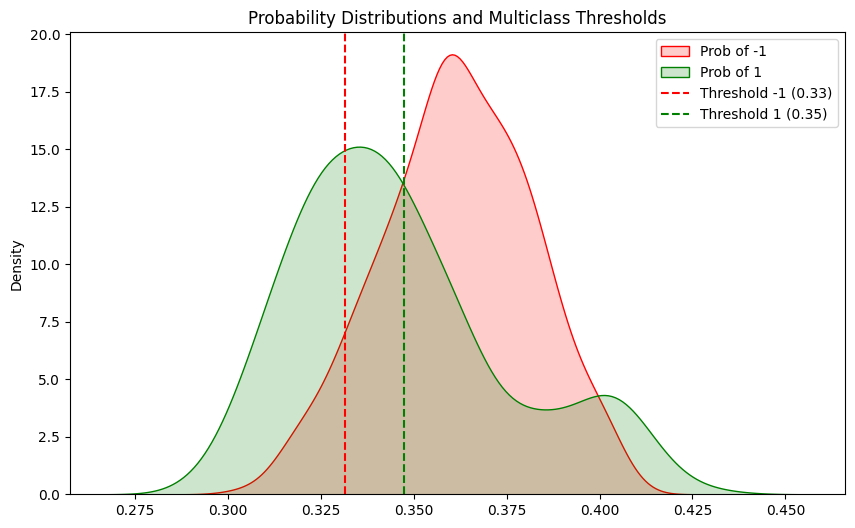

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score

def predict_multiclass(y_probs, t_minus, t_plus):
    """
    y_probs: array of shape (n_samples, 3)
             Assumes columns are ordered: [-1, 0, 1]
    """
    # Initialize with the minority class (0)
    y_pred = np.zeros(y_probs.shape[0], dtype=int)

    # Assign -1 if its probability exceeds t_minus
    y_pred[y_probs[:, 0] > t_minus] = -1

    # Assign 1 if its probability exceeds t_plus
    # (If both exceed, 1 takes precedence here, or use np.argmax)
    y_pred[y_probs[:, 2] > t_plus] = 1

    return y_pred

# 1. Get full probabilities for all 3 classes
y_probs = best_rf_model.predict_proba(sub_X_test)

# 2. Optimization: Find the thresholds that maximize Macro F1
# (Macro F1 is best here because it weights the 3% class equally)
best_f1 = 0
best_thresholds = (0.5, 0.5)

for t_m in np.linspace(0.3, 0.6, 20):
    for t_p in np.linspace(0.3, 0.6, 20):
        temp_preds = predict_multiclass(y_probs, t_m, t_p)
        score = f1_score(y_test, temp_preds, average='macro')
        if score > best_f1:
            best_f1 = score
            best_thresholds = (t_m, t_p)

t_minus, t_plus = best_thresholds

# 3. Final Evaluation
y_pred_final = predict_multiclass(y_probs, t_minus, t_plus)

print(f"Optimal Thresholds: -1 @ {t_minus:.2f}, 1 @ {t_plus:.2f}")
print(classification_report(y_test, y_pred_final))

# 4. Visualizing the Decision Zones
plt.figure(figsize=(10, 6))
sns.kdeplot(y_probs[:, 0], label='Prob of -1', color='red', fill=True, alpha=0.2)
sns.kdeplot(y_probs[:, 2], label='Prob of 1', color='green', fill=True, alpha=0.2)
plt.axvline(t_minus, color='red', linestyle='--', label=f'Threshold -1 ({t_minus:.2f})')
plt.axvline(t_plus, color='green', linestyle='--', label=f'Threshold 1 ({t_plus:.2f})')
plt.title("Probability Distributions and Multiclass Thresholds")
plt.legend()
plt.show()

## Model fitting check with manual threshold setiting

In [127]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, accuracy_score

def apply_thresholds(y_probs, t1, t2):
    """
    Applies two thresholds to convert 3-class probabilities into labels.
    Assumes y_probs has columns for classes [-1, 0, 1] in that order.
    """
    # Default to class 0 (the middle ground)
    y_pred = np.zeros(y_probs.shape[0])

    # If prob of -1 is high enough, assign -1
    y_pred[y_probs[:, 0] > t1] = -1

    # If prob of 1 is high enough, assign 1
    # Note: If both are high (rare), class 1 takes precedence here
    y_pred[y_probs[:, 2] > t2] = 1

    return y_pred

def find_best_multi_threshold(y_true, y_probs):
    best_f1 = -1
    best_thresholds = (0.33, 0.33)

    # Search space for thresholds (0.1 to 0.7)
    # We focus on thresholds for class -1 and class 1
    threshold_range = np.linspace(0.1, 0.7, 20)

    for t_minus in threshold_range:
        for t_plus in threshold_range:
            y_pred = apply_thresholds(y_probs, t_minus, t_plus)

            # Using 'macro' F1 because class 0 is so small
            current_f1 = f1_score(y_true, y_pred, average='macro')

            if current_f1 > best_f1:
                best_f1 = current_f1
                best_thresholds = (t_minus, t_plus)

    return best_thresholds, best_f1

# --- Example Usage ---
# Ensure y_probs is from model.predict_proba(X_test)
# which returns a [n_samples, 3] array
y_probs = best_rf_model.predict_proba(sub_X_test)

(t_minus, t_plus), best_f1 = find_best_multi_threshold(y_test, y_probs)

print(f"Optimal Thresholds: Class(-1) @ {t_minus:.2f}, Class(1) @ {t_plus:.2f}")
print(f"Best Macro F1-Score: {best_f1:.4f}")

# Final Evaluation
y_pred = apply_thresholds(y_probs, t_minus, t_plus)

print("\n--- Final Test Set Performance (Multi-Class) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Optimal Thresholds: Class(-1) @ 0.10, Class(1) @ 0.35
Best Macro F1-Score: 0.3655

--- Final Test Set Performance (Multi-Class) ---
Accuracy: 0.5526
              precision    recall  f1-score   support

          -1       0.54      0.72      0.62       206
           0       0.00      0.00      0.00        11
           1       0.58      0.41      0.48       201

    accuracy                           0.55       418
   macro avg       0.37      0.38      0.37       418
weighted avg       0.54      0.55      0.53       418



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Diagnosis

## Learning Curve

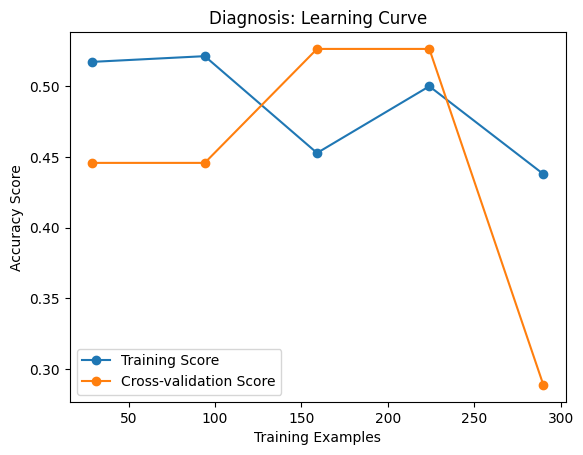

In [128]:
# Execution
plot_learning_curve(best_rf_model, sub_X_train, y_train)

## Calibration Diagnostic

In [129]:
import pandas as pd

# 1. Get the probabilities
rf.fit(sub_X_train, y_train)
y_prob = best_rf_model.predict_proba(sub_X_test)[:, 1]

# 2. Create a DataFrame for analysis
results = pd.DataFrame({
    'actual': y_test,
    'prob': y_prob
})

# 3. Define confidence tiers
def check_precision(df, low, high):
    subset = df[(df['prob'] >= low) & (df['prob'] < high)]
    if len(subset) == 0: return 0, 0
    precision = subset['actual'].mean()
    return precision, len(subset)

# Diagnostic Printout
print("Confidence Tier | Precision (Accuracy) | Sample Count")
print("-" * 50)
for low, high in [(0, 0.35), (0.35, 0.45), (0.45, 0.55), (0.55, 0.65), (0.65, 1.0)]:
    prec, count = check_precision(results, low, high)
    # For low tiers, 'precision' is actually the accuracy of predicting Class 0
    if low < 0.45:
        display_prec = 1 - prec
        label = "Class 0"
    else:
        display_prec = prec
        label = "Class 1"
    print(f"{low:.2f} - {high:.2f}   | {display_prec:.2%}- {label}       | {count}")

Confidence Tier | Precision (Accuracy) | Sample Count
--------------------------------------------------
0.00 - 0.35   | 100.00%- Class 0       | 389
0.35 - 0.45   | 117.24%- Class 0       | 29
0.45 - 0.55   | 0.00%- Class 1       | 0
0.55 - 0.65   | 0.00%- Class 1       | 0
0.65 - 1.00   | 0.00%- Class 1       | 0
